# DMRG Single site: ITensorMPS version

NOTE: we are including a module containing some functions that will be used in the notebook.

In [1]:
using Pkg
Pkg.activate("..")
using ITensors
using ITensorMPS
using LinearAlgebra
using Test
using Printf

  Activating project at `~/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/Work/Workspace/Unimi/Corsi/TN_Ulm/Materiale_dispense/TN_Notebooks`


Here we define a first, simple and highly unoptimized version of the single site DMRG algorithm.

## Definition of the system

As customary in these exploratory notebooks we use systems of spin-$1/2$ particles. Let's start simple. 

In [2]:
nn = 20
system = siteinds("S=1/2", nn);

In [15]:
jj = 1.0
g = 30.0
opsum = OpSum()
for j in 1:nn-1
    opsum += -jj , "S-", j, "S+", j+1
    opsum += -jj, "S+", j, "S-", j+1
end
for j in 1:nn-1
    opsum += -g * jj,"Z", j, "Z", j+1
end
ham = MPO(opsum, system);

In [16]:
bond_dim = 2
psi0 = random_mps(ComplexF64, system, linkdims=bond_dim)

20-element MPS:
 ((dim=2|id=514|"S=1/2,Site,n=1"), (dim=2|id=800|"Link,l=1"))
 ((dim=2|id=800|"Link,l=1"), (dim=2|id=65|"S=1/2,Site,n=2"), (dim=2|id=429|"Link,l=2"))
 ((dim=2|id=429|"Link,l=2"), (dim=2|id=886|"S=1/2,Site,n=3"), (dim=2|id=106|"Link,l=3"))
 ((dim=2|id=106|"Link,l=3"), (dim=2|id=893|"S=1/2,Site,n=4"), (dim=2|id=86|"Link,l=4"))
 ((dim=2|id=86|"Link,l=4"), (dim=2|id=255|"S=1/2,Site,n=5"), (dim=2|id=591|"Link,l=5"))
 ((dim=2|id=591|"Link,l=5"), (dim=2|id=517|"S=1/2,Site,n=6"), (dim=2|id=559|"Link,l=6"))
 ((dim=2|id=559|"Link,l=6"), (dim=2|id=477|"S=1/2,Site,n=7"), (dim=2|id=23|"Link,l=7"))
 ((dim=2|id=23|"Link,l=7"), (dim=2|id=675|"S=1/2,Site,n=8"), (dim=2|id=228|"Link,l=8"))
 ((dim=2|id=228|"Link,l=8"), (dim=2|id=11|"S=1/2,Site,n=9"), (dim=2|id=704|"Link,l=9"))
 ((dim=2|id=704|"Link,l=9"), (dim=2|id=977|"S=1/2,Site,n=10"), (dim=2|id=322|"Link,l=10"))
 ((dim=2|id=322|"Link,l=10"), (dim=2|id=473|"S=1/2,Site,n=11"), (dim=2|id=542|"Link,l=11"))
 ((dim=2|id=542|"Link,l=11"), (di

In [17]:
nsweeps = 5 # number of sweeps is 5
maxdim = [10,20,100,100,200] # gradually increase states kept
cutoff = [1E-10] # desired truncation error

1-element Vector{Float64}:
 1.0e-10

In [18]:
energy,psi = dmrg(ham,psi0;nsweeps,maxdim,cutoff)


After sweep 1 energy=-569.9989832446811  maxlinkdim=6 maxerr=9.77E-11 time=0.014
After sweep 2 energy=-569.9999999999994  maxlinkdim=1 maxerr=7.90E-11 time=0.009
After sweep 3 energy=-570.0  maxlinkdim=1 maxerr=4.48E-44 time=0.019
After sweep 4 energy=-570.0000000000011  maxlinkdim=1 maxerr=5.47E-48 time=0.015
After sweep 5 energy=-570.0000000000006  maxlinkdim=1 maxerr=1.64E-47 time=0.007


(-570.0000000000006, MPS(20))

Find the best solution with current bond dimension

In [58]:
using Plots

In [59]:
sum(energies)/length(energies)

-10.071246376266377

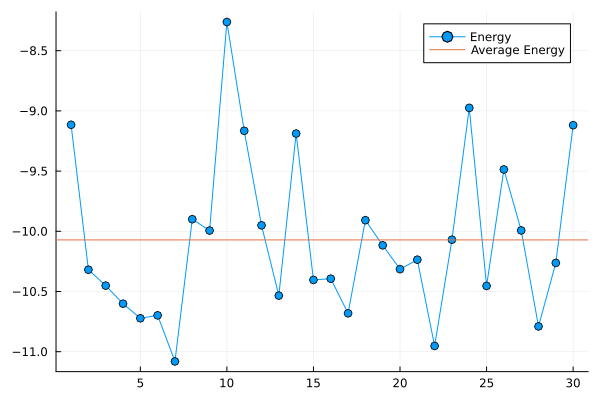

In [60]:
plot(energies, marker=:o, label="Energy")
hline!([sum(energies)/length(energies)], label="Average Energy")

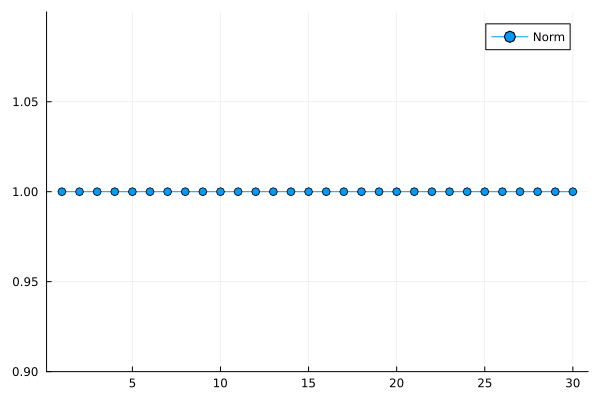

In [38]:
plot(norms, marker=:o, label="Norm",ylims=(0.9,1.1))

In [79]:
#Expand the bond dimension of the state with the minimum energy to the maximum bond dimension allowed, and orthogonalize it to prepare it for the next steps (e.g. time evolution, or targeting excited states).
newpsi0,over = stretchBondDim(bestState, 64)

(MPS(20), 1.0000000000000098 - 7.026765318060342e-16im)

In [80]:
psi0 = newpsi0
orthogonalize!(psi0, 1)
H = ham
N = length(psi0)
psi = copy(psi0)
#R = build_right_blocks(psi, H)
#L = Vector{ITensor}(undef, N)  # L[k] viene riempito on-the-fly
maxdim::Int=100
cutoff::Float64=1e-14
tol_davidson::Float64=1e-14
maxiter_davidson::Int=30
E = 0.0

energies = Float64[]
bestState = copy(psi0)
norms = Float64[]
min_energy::Float64 = Inf
pos_min_energy::Int = 0

fileout = open("dmrg_single_site_output.txt", "w")

nsweeps = 30

for sweep in 1:nsweeps

    println("Sweep: $sweep")
    # ── Sweep L -> R ──────────────────────────────────────────
    # ── Reconstruct right blocks starting from the right. Right blocks are not changed during a L -> R  sweep ──
    R = build_right_blocks(psi, H)
    
    # Left blocks are built on the finally
    L = Vector{ITensor}(undef, N)

    #Inline definition of the apply_H function for the Davidson algorithm
    #Scope: visible within the loop, can access L and R which are updated at each iteration
    
    #Left-sweep: k=1,...,N-1
    for k in 1:N-1
        apply_H = v -> begin
            Hv = v * H[k]
            if k > 1; Hv = Hv * L[k-1]; end
            Hv = Hv * R[k+1]
            noprime(Hv)
        end

        println(fileout,"L->R: Updating site $k sweep $sweep")
        E, psi[k] = davidson(apply_H, psi[k]; maxiter=maxiter_davidson, tol=tol_davidson)

        #psi[k] updated. The overall dimension chi_{k-1} x d_k x chi_{k} of the output is the same as the input.
        #Now we need to shift the orthogonality center to k+1, which means:
        #psi[k] -> left-orthogonal 
        #psi[k+1] -> OC

        #Determine the left indices to perform the SVD. For k=1 we have only the physical index, while for k>1 we have both the left link and the physical index.
        #Note: linkind(psi, k-1) is the left link index of psi[k], while siteind(psi, k) is the physical index of psi[k]. The SVD will be performed by grouping these indices together as "left" indices, and the remaining right link index (if k>1) will be the "right" index.
        linds = (k == 1) ? [siteind(psi, k)] :
                           [linkind(psi, k-1), siteind(psi, k)]

        #Perform the SVD
        #We set cutoff=0 to keep all the singular values The lefttags argument is used to tag the left link index of U with "Link,l=k", which will be useful for the next iteration when we need to identify this index.
        #Note that we assign tags to the left and right link indices of U,S, and V, which will be useful for the next iteration when we need to identify these indices after the shift of the OC is completed. 
        U, S, V = svd(psi[k], linds; cutoff=0,
                      lefttags="Link,l=$k",righttags="Link,l=$k")
        #psi[k] is now left-orthogonal, while psi[k+1] is updated to be the new OC tensor by contracting S and V with the old psi[k+1]
        psi[k]   = U
        psi[k+1] = S * dag(V) * psi[k+1]

        #We update(actually assign) the left block L[k] on-the-fly using the updated psi[k]. This is possible because L[k] depends only on psi[1],...,psi[k], which are all updated at this point. In this way we avoid to reconstruct the left blocks from scratch at each iteration, which would be more expensive.
        L[k] = (k == 1) ?
            psi[k] * H[k] * dag(prime(psi[k])) :
            L[k-1] * psi[k] * H[k] * dag(prime(psi[k]))
    end #L->R sweep
    
    println(fileout,"After L->R sweep, sweep = $sweep, E = $E")

    #After the end of L->R we have all the L blocks L[1],...,L[N-1] updated.  The site N is the OC, and it will be updated during the R->L sweep.
#     # ── Sweep R -> L ──────────────────────────────────────────

# The blocks R[k],k=N,N-1,2 are built on the fly after the update of psi[k] during the R->L sweep, starting from the rightmost site. This is possible because R[k] depends only on psi[k],...,psi[N].

R = Vector{ITensor}(undef, N)


    for k in N:-1:2

        println(fileout,"R->L: Updating site $k sweep $sweep")
        apply_H = v -> begin
            Hv = v * H[k]
            if k < N; Hv = Hv * R[k+1]; end
            Hv = Hv * L[k-1]
            noprime(Hv)
        end


        E, psi[k] = davidson(apply_H, psi[k]; maxiter=maxiter_davidson, tol=tol_davidson)

        #Treat the site index and the right link index of psi[k] as "row" indices for the SVD.
        rinds = (k == N) ? [siteind(psi, k)] :                        
        [siteind(psi, k), linkind(psi, k)]
        
        #Perform the SVD to shift the OC to the left. Note that for k=N we have only the physical index, while for k<N we have both the physical index and the right link index.

        U, S, V = svd(psi[k], rinds;  cutoff=0,lefttags="Link,l=$(k-1)",righttags="Link,l=$(k-1)")

        psi[k]   = U
        psi[k-1] = psi[k-1] * S * dag(V)


        # build R[k] with updated psi[k]
        R[k] = (k==N) ? psi[k] * H[k] * dag(prime(psi[k])) : psi[k] * H[k] * dag(prime(psi[k])) * R[k+1]
               

    end #End of R->L sweep
    flush(fileout)
    en = real(inner(psi', ham, psi))
    @printf("sweep = %d | E = %.12f | maxdim = %d\n",
             sweep, en, maxlinkdim(psi))
    
    #store intermediate energies and states
    push!(energies, en)
    push!(norms, norm(psi))
    if en < min_energy
        min_energy = en
        pos_min_energy = sweep
        bestState = copy(psi)
        end
end

close(fileout)

Sweep: 1
sweep = 1 | E = -10.431435156604 | maxdim = 64
Sweep: 2
sweep = 2 | E = -9.281998888312 | maxdim = 64
Sweep: 3
sweep = 3 | E = -10.713206702611 | maxdim = 64
Sweep: 4
sweep = 4 | E = -10.445223724960 | maxdim = 64
Sweep: 5
sweep = 5 | E = -8.841240876697 | maxdim = 64
Sweep: 6
sweep = 6 | E = -10.520780296129 | maxdim = 64
Sweep: 7
sweep = 7 | E = -10.723392365661 | maxdim = 64
Sweep: 8
sweep = 8 | E = -10.142067651024 | maxdim = 64
Sweep: 9
sweep = 9 | E = -10.034896306690 | maxdim = 64
Sweep: 10
sweep = 10 | E = -9.815019927560 | maxdim = 64
Sweep: 11
sweep = 11 | E = -10.723615451647 | maxdim = 64
Sweep: 12
sweep = 12 | E = -10.429340594622 | maxdim = 64
Sweep: 13
sweep = 13 | E = -9.559183587615 | maxdim = 64
Sweep: 14
sweep = 14 | E = -9.410472382350 | maxdim = 64
Sweep: 15
sweep = 15 | E = -10.774535416499 | maxdim = 64
Sweep: 16
sweep = 16 | E = -10.275204393731 | maxdim = 64
Sweep: 17
sweep = 17 | E = -10.264292442847 | maxdim = 64
Sweep: 18
sweep = 18 | E = -9.9763746

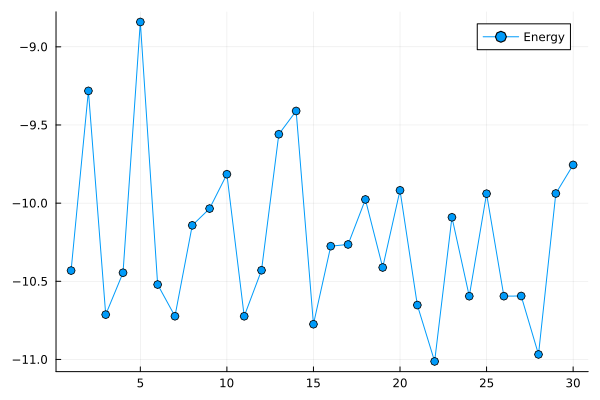

In [81]:
plot(energies, marker=:o, label="Energy")

We can continue with additional iterations with increasing bond dimension and number of sweeps.
At the end we can conclude that:
- the idea of DMRG is clear
- the practice of DMRG is quite more complicated: getting stuck on local minima is quite likely, and a meaningful exploration of the Hilbert space is not trivial to define.


In [64]:
psiRef = copy(bestState)

20-element MPS:
 ((dim=2|id=788|"S=1/2,Site,n=1"), (dim=2|id=265|"Link,l=1"))
 ((dim=2|id=451|"S=1/2,Site,n=2"), (dim=4|id=745|"Link,l=2"), (dim=2|id=265|"Link,l=1"))
 ((dim=2|id=925|"S=1/2,Site,n=3"), (dim=8|id=305|"Link,l=3"), (dim=4|id=745|"Link,l=2"))
 ((dim=2|id=581|"S=1/2,Site,n=4"), (dim=16|id=724|"Link,l=4"), (dim=8|id=305|"Link,l=3"))
 ((dim=2|id=344|"S=1/2,Site,n=5"), (dim=32|id=927|"Link,l=5"), (dim=16|id=724|"Link,l=4"))
 ((dim=2|id=42|"S=1/2,Site,n=6"), (dim=48|id=516|"Link,l=6"), (dim=32|id=927|"Link,l=5"))
 ((dim=2|id=165|"S=1/2,Site,n=7"), (dim=48|id=866|"Link,l=7"), (dim=48|id=516|"Link,l=6"))
 ((dim=2|id=116|"S=1/2,Site,n=8"), (dim=48|id=908|"Link,l=8"), (dim=48|id=866|"Link,l=7"))
 ((dim=2|id=690|"S=1/2,Site,n=9"), (dim=48|id=688|"Link,l=9"), (dim=48|id=908|"Link,l=8"))
 ((dim=2|id=28|"S=1/2,Site,n=10"), (dim=48|id=999|"Link,l=10"), (dim=48|id=688|"Link,l=9"))
 ((dim=2|id=895|"S=1/2,Site,n=11"), (dim=48|id=41|"Link,l=11"), (dim=48|id=999|"Link,l=10"))
 ((dim=2|id=673

In [76]:
norm(S)

1.000000000000003

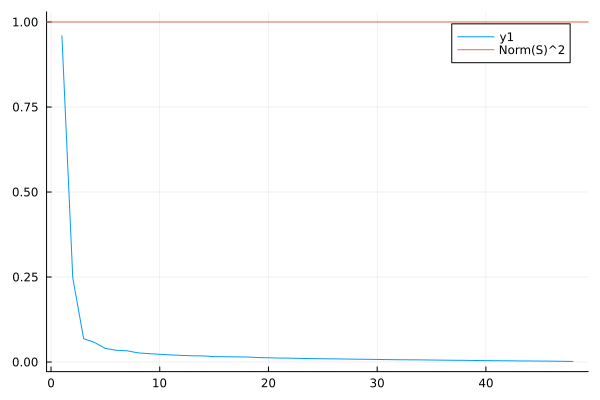

In [78]:
whichSite = 13
orthogonalize!(psiRef, whichSite)
leftindices = [siteind(psiRef, whichSite), linkind(psiRef, whichSite-1)]
U,S,V = svd(psiRef[whichSite], leftindices; cutoff=0)
plot(diag(S))
hline!([norm(S)^2], label="Norm(S)^2")